In [1]:
import numpy as np
import pandas as pd
import string
import matplotlib.pyplot as plt
from os import listdir
from os.path import isfile, join
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import PowerNorm

In [2]:
folder_path = "/data/MBC3/"
intro_end_list = [414,545,355,351,330,693,294,1667,800,547]
facillitator_list = [[3], [1], [2,3], [5,0], [2], [0,2], [3,6], [6,2], [0,2], [0]]

file_list = [f for f in listdir(folder_path) if f.startswith("MBC3") and f.endswith(".csv")]
file_list.sort()
dfs = []

for i,file_name in enumerate(file_list):
    file_path = join(folder_path, file_name)
    df = pd.read_csv(file_path)
    df = df[df['start']>intro_end_list[i]]
    dfs.append(df)

In [3]:
def combine_turn(df, thres=0.4):
    df = df[df['confidence']>thres].reset_index(drop=True)
    df2 = pd.DataFrame({
    'duration': df['end'] - df['start'],
    'speaker_id': df['speaker_id']})
    # Step 2: Collapse consecutive identical IDs
    # Create a group identifier that increments when the ID changes
    group = (df2['speaker_id'] != df2['speaker_id'].shift()).cumsum()

    # Group by that identifier and sum durations while keeping the first ID
    result = df2.groupby(group).agg({'duration': 'sum', 'speaker_id': 'first'}).reset_index(drop=True)
    return result

In [4]:
def turn_switch(df, thres=0.4):
    cleaned_df = df
    cleaned_df['prev_speaker_id'] = df['speaker_id'].shift(1)
    transition_df = cleaned_df[cleaned_df['speaker_id']!=cleaned_df['prev_speaker_id']].reset_index(drop=True)
    transition_df = transition_df.dropna().reset_index(drop=True)
    transition_df['prev_speaker_id'] = transition_df['prev_speaker_id'].astype(int)
    return transition_df

In [5]:
def transition_matrix(df):
    first_column = 'speaker_id'
    second_column = 'prev_speaker_id'
    states = df[first_column].unique()
    states.sort()
    transition_matrix_turn = pd.DataFrame(0, index=states, columns=states, dtype=float)
    transition_matrix_time = pd.DataFrame(0, index=states, columns=states, dtype=float)
    for i in range(len(df)):
        current_state = df[first_column].iloc[i]
        next_state = df[second_column].iloc[i]
        transition_matrix_turn.loc[current_state, next_state] += 1
        transition_matrix_time.loc[current_state, next_state] += df.iloc[i]['duration']
    return transition_matrix_time, transition_matrix_turn

In [6]:
session_index = [0,2,4,6,7,8,9,10,11,14]
#facilitator_list = [[3], [1], [2,3], [5,0], [2], [0,2], [3,6], [6,2], [0,2], [0]]
name_dfs = [[6,8,1,9,5,4,2,7,0],
            [5,8,3,0,2,6,9,7],
           [7,13,9,0,5,4,6,8,1],
            [8,2,9,3,1,6,10,4],
           [6,11,7,10,0,4,5,1,8,3],
            [4,6,9,7,1,3,10,8,5],
           [0,1,7,9,4,5,2,8,10],
           [10,3,11,4,5,9,8,0,1],
           [7,8,6,11,5,4,9,10,3,1],
           [7,5,9,6,8,1,3,2,4]
           ]
            


trans_matrix_turn_list = []
trans_matrix_time_list = []


first_column = 'speaker_id'
second_column = 'prev_speaker_id'

for i in range(len(dfs)):
    tmp_combined_df = combine_turn(dfs[i])
    transition_df = turn_switch(tmp_combined_df)
    
    tmp_states = name_dfs[i]
    tmp_transition_matrix_turn = pd.DataFrame(0, index=tmp_states, columns=tmp_states, dtype=float)
    tmp_transition_matrix_time = pd.DataFrame(0, index=tmp_states, columns=tmp_states, dtype=float)
    
    for j in range(len(transition_df)):
        current_state = transition_df[first_column].iloc[j] #'order'
        next_state = transition_df[second_column].iloc[j] #'order'
        if current_state in tmp_states and next_state in tmp_states:
        
            tmp_transition_matrix_turn.loc[current_state, next_state] += 1 #in transition matrix, the state is 'name'
            tmp_transition_matrix_time.loc[current_state, next_state] += transition_df.iloc[j]['duration']
            
    
    trans_matrix_turn_list.append(tmp_transition_matrix_turn)
    trans_matrix_time_list.append(tmp_transition_matrix_time)

In [7]:
#real data
#Facilitator already removed
N = 8
result_array = np.zeros((N,N))
data_list = []
for i in range(len(trans_matrix_time_list)):
    tmp = trans_matrix_time_list[i].to_numpy()
    #tmp = np.delete(tmp, facillitator_list[i], axis=0)  # Delete rows
    #tmp = np.delete(tmp, facillitator_list[i], axis=1)  # Delete columns
    row_sums = np.sum(tmp, axis=1)
    sorted_indices = np.argsort(row_sums)[::-1]
    sorted_array = tmp[np.ix_(sorted_indices, sorted_indices)]
    #sorted_array = np.sort(sorted_array, axis=1)[:, ::-1]
    #data_list.append(sorted_array[:N, :N]/np.sum(sorted_array[:N, :N]))
    data_list.append(sorted_array/np.sum(sorted_array))
    result_array += sorted_array[:N, :N]/np.sum(sorted_array[:N, :N])
result_array = result_array/len(trans_matrix_time_list)
#result_array = result_array/np.max(result_array)
#result_array[:,-1] = 0
result_array = result_array/np.sum(result_array)

In [8]:
#dynamical model
#prediction for each session and individual
session_index = [0,2,4,6,7,8,9,10,11,14]
model_list = []
model_array = np.zeros((N,N))

for j,i in enumerate(session_index):
    turn_df = pd.read_csv('/data/reciprocal_predtime_MBC3/'+str(i)+'.csv',header=None)
    tmp = turn_df.values
    row_sums = np.sum(tmp, axis=1)
    sorted_indices = np.argsort(row_sums)[::-1]
    sorted_array = tmp[np.ix_(sorted_indices, sorted_indices)]
    #sorted_array = np.sort(sorted_array, axis=1)[:, ::-1]
    model_list.append(sorted_array/sorted_array.sum())
    model_array += sorted_array[:N, :N]/np.sum(sorted_array[:N, :N])

model_array = model_array/len(session_index)
model_array = model_array/np.sum(model_array)
                                         

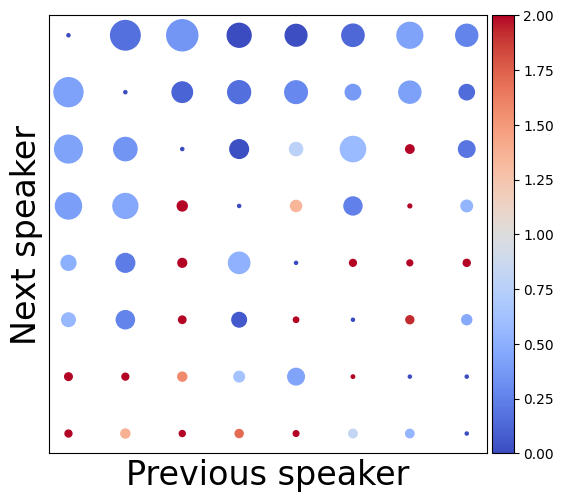

In [9]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import PowerNorm
# Visualize the prediction results normalized
size_matrix = result_array   # Size values

color_matrix = np.zeros((8,8))
for i in range(8):
    for j in range(8):
        if result_array[i,j] != 0:
            color_matrix[i,j] = abs(result_array[i,j] - model_array[i,j])/result_array[i,j]
            #color_matrix[i,j] = (model_array[i,j] - result_array[i,j])/result_array[i,j]
#color_matrix = abs(result_array - model_array)        # Color values

# Create grid of positions
x, y = np.meshgrid(np.arange(8), np.arange(8))

# Flatten all for scatter plot
x_flat = x.flatten()
y_flat = y.flatten()

sizes = size_matrix.flatten()
size_min, size_max = 5, 500
size_norm = (size_matrix - size_matrix.min()) / (size_matrix.max() - size_matrix.min())
sizes = size_norm * (size_max - size_min) + size_min

colors = color_matrix.flatten()

vmin, vmax = 0, 2.0

norm = PowerNorm(gamma=0.6, vmin=vmin, vmax=vmax)
# Plot
fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(x_flat, y_flat, s=sizes, c=colors, cmap='coolwarm', vmin=vmin, vmax=vmax)
#scatter = ax.scatter(x_flat, y_flat, s=sizes, c=colors, cmap="gray", vmin=vmin, vmax=vmax)

ax.invert_yaxis()  # Invert y-axis if you want it to look like matrix layout
ax.set_xticks(range(8))
ax.set_yticks(range(8))
ax.grid(True, linestyle='--', alpha=0.3)

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('Previous speaker', fontsize=24)
ax.set_ylabel('Next speaker', fontsize=24)

ax.set_aspect('equal')

#ax.set_facecolor("0.95")

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
plt.colorbar(scatter, cax=cax)
plt.savefig("/results/figure2.pdf", format='pdf', bbox_inches="tight")
plt.show()